In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import time
import tqdm
import helpers

import environments
import environments.bicycle as bicycle

import controllers.clothoids as clothoids
import controllers.purepursuit as purepursuit

import metrics

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [ ]:
env = environments.bicycle.BicycleCarEnv(
    road_network=bicycle.RoadNetwork(roads=[
        bicycle.create_rectangular_track(
            center=(50.0, 50.0),
            length=80.0,
            height=40.0,
            turn_radius=8.0,
            width=8.0,
        )
    ]),
    render_mode="rgb_array",
    spawn=((50.0, 30.0), 0.0),
    goal=((10.0, 50.0), 2.0),
    obstacles=[
        bicycle.Circle(center=(90, 50), radius=1.0),
    ],
    solid_road_borders=True,
    # 0.1second = 100ms per step
    dt=0.1
)

In [10]:
controller = clothoids.ClothoidTentaclesController(
    num_tentacles=41,
    # t0=7.0,
    t0=10.0,
    # l0=5.0,
    l0=10.0,
    num_points_per_tentacle=64,

    wheelbase=env.WHEELBASE,
    vehicle_width=env.CAR_WIDTH,
    max_lateral_acceleration=4.0,
    max_deceleration=1.5,

    # clearance, curvature, trajectory
    weights=(0.1, 0.2, 0.5),

    # TODO: I set a target velocity of 3.5 but the controller always goes at 5.0 m/s
    target_velocity=3.5,
    kp_velocity=2.0,
)

In [35]:
environments.bicycle.wrappers.observations.WithObstaclesInfo
environments.bicycle.wrappers.observations.WithDynamicsInfo
environments.bicycle.wrappers.observations.WithPathInfo
environments.bicycle.wrappers.observations.WithRoadInfo

environments.bicycle.wrappers.observations.with_road_info.WithRoadInfo

In [ ]:
wrappers = lambda env: environments.bicycle.wrappers.observations.WithObstaclesInfo(
    environments.bicycle.wrappers.observations.WithPathInfo(
        environments.bicycle.wrappers.observations.WithRoadInfo(
            environments.bicycle.wrappers.observations.WithDynamicsInfo(
                env
            )
        )
    )
)

[path.#points]: 557
[observation]: dict_keys(['base.position', 'base.heading', 'base.velocity'])


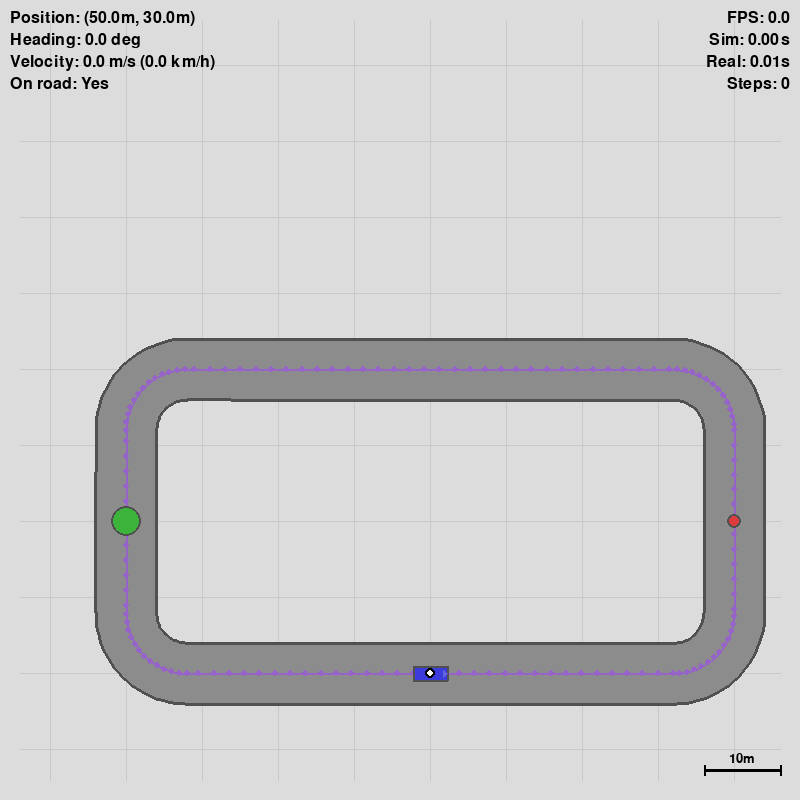

In [92]:
env = environments.bicycle.BicycleCarEnv(
    road_network=bicycle.RoadNetwork(roads=[
        bicycle.create_rectangular_track(
            center=(50.0, 50.0),
            length=80.0,
            height=40.0,
            turn_radius=8.0,
            width=8.0,
        )
    ]),
    render_mode="rgb_array",
    spawn=((50.0, 30.0), 0.0),
    goal=((10.0, 50.0), 2.0),
    obstacles=[
        bicycle.Circle(center=(90, 50), radius=1.0),
    ],
    solid_road_borders=True,
    # 0.1second = 100ms per step
    dt=0.1
)

env = environments.bicycle.wrappers.observations.WithBaseInfo(env)
# env = environments.bicycle.wrappers.observations.WithObstaclesInfo(env)
# env = environments.bicycle.wrappers.observations.WithPathInfo(env)
# env = environments.bicycle.wrappers.observations.WithRoadInfo(env)
# env = environments.bicycle.wrappers.observations.WithDynamicsInfo(env)

print("[path.#points]:", len(env.unwrapped.path))
# print("[path[:10]]:", env.unwrapped.path[:10])

observation, info = env.reset()

print("[observation]:", observation.keys())

helpers.preview(env, False)

In [93]:
# TODO: start simple, using the base info wrapper teach the model to drive, it'll learn 100% the track and will take time, no generalization
# TODO: progressively add more info to the observation space and see how it improves generalization

In [ ]:
obs, info = env.reset()

for i in range(10):
    action = controller.get_action(
        observation=obs,
        path=env.path,
        obstacles=env.obstacles,
        road_network=env.road_network,
        max_steering=env.MAX_STEERING,
        max_acceleration=env.MAX_ACCELERATION,
    )
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.overlay_manager.clear()
    controller.draw_debug(env, obs, env.path)
    
    helpers.preview(env)

    if terminated or truncated:
        break

env.close()

In [ ]:
# Get episode data and compute metrics
episode_data = env.get_episode_data()
# print(f"Episode finished after {i+1} steps")

# Compute metrics
print("\n=== Performance Metrics ===")

cte_metrics = metrics.compute_cross_track_error(
    positions=episode_data['positions'],
    reference_path=env.path,
)
print(f"CTE RMS: {cte_metrics['cte_rms']:.3f} m")

smoothness_metrics = metrics.compute_steering_smoothness(
    steering_angles=episode_data['steering_angles'],
    dt=env.dt,
)
print(f"Steering Jerk RMS: {smoothness_metrics['steering_jerk_rms']:.3f} rad/s³")

success = metrics.compute_success_rate([episode_data])
print(f"Success: {'Yes' if success == 1.0 else 'No'}")